# DeepSeek Risk-Factor Listing Eval

Este notebook ejecuta el primer baseline LLM del proyecto: dado el texto completo de `Item 1A. Risk Factors` de los 10-K de Guidewire Software, le pedimos a DeepSeek que liste los factores de riesgo explícitos que la compañía ya declaró.

La idea no es detectar todavía riesgos ocultos. Primero comprobamos algo más básico y necesario: que el modelo puede recuperar de forma fiable los encabezados de riesgos existentes en el informe. Si falla aquí, no tendría sentido pedirle comparaciones más sutiles de tono, contradicciones o aparición/desaparición de riesgos.

El notebook usa los módulos de evaluación del proyecto, lee `DEEPSEEK_API_KEY` y `DEEPSEEK_MODEL` desde `.env`, y ejecuta todos los casos disponibles en `eval.json` por defecto.


## Qué se comprueba

Antes de llamar al modelo comprobamos el fixture:

- `eval.json` se puede cargar correctamente.
- Cada caso tiene `input.text`, es decir, el texto completo que recibirá el modelo.
- El número esperado de factores de riesgo coincide con la lista de `expected_result_by_llm.risk_factors`.
- El recuento de palabras guardado en metadata coincide con el texto embebido.

Después de llamar al modelo comprobamos la salida:

- La respuesta debe ser JSON válido.
- Extraemos `risk_factors[]` de la respuesta del modelo.
- Comparamos cada título esperado contra el mejor título predicho que aún no haya sido usado.
- La comparación normaliza mayúsculas, puntuación y espacios, y usa similitud textual para permitir pequeñas diferencias de redacción.
- Un caso pasa si cumple los umbrales de `recall`, `precision` y similitud por título.

Métricas principales:

- `recall`: qué proporción de riesgos esperados recuperó el modelo.
- `precision`: qué proporción de riesgos predichos eran realmente esperados.
- `matched_count`: número de títulos esperados que pudieron emparejarse con una predicción.
- `missing`: títulos esperados que el modelo no recuperó.
- `unexpected`: títulos predichos que no estaban en el expected result.


## Cómo sabemos si el modelo acertó

El resultado esperado vive en `expected_result_by_llm.risk_factors[].title`. La salida del modelo se lee desde `risk_factors[].title`.

La comparación no exige que el texto sea byte a byte idéntico. Primero normalizamos los títulos: minúsculas, comillas, `&` como `and`, puntuación y espacios. Después comparamos cada título esperado contra el mejor título predicho que todavía no haya sido usado.

Un título se considera recuperado si su similitud textual es al menos `MATCH_THRESHOLD`, que por defecto es `0.88`.

Para cada año calculamos:

- `expected_count`: cuántos encabezados esperábamos según `eval.json`.
- `predicted_count`: cuántos encabezados devolvió el modelo.
- `matched_count`: cuántos encabezados esperados se emparejaron con una predicción.
- `recall = matched_count / expected_count`: cobertura de lo esperado.
- `precision = matched_count / predicted_count`: limpieza de lo predicho.
- `missing`: encabezados esperados que el modelo no recuperó.
- `unexpected`: encabezados que el modelo añadió y no estaban en el expected.

Un caso pasa si `recall >= 0.98` y `precision >= 0.95`. La ejecución completa pasa solo si pasan todos los años. Así evitamos aprobar una respuesta que parezca razonable pero omita riesgos importantes o invente demasiados encabezados.


In [1]:
from pathlib import Path
import json
import sys
from statistics import mean

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'eval.json').exists() and (candidate / 'src').is_dir():
            return candidate
    raise FileNotFoundError('Could not find project root with eval.json and src/.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams.update({
    'figure.figsize': (11, 4),
    'axes.grid': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PROJECT_ROOT


PosixPath('PROJECT_ROOT')

## Cargar y validar el fixture

`eval.json` es autocontenido: no lee ficheros SEC locales ni outputs de scraping. Cada caso incluye el texto completo que se manda al modelo y el resultado esperado que usaremos para evaluar.


In [2]:
from src.llm.deepseek import DeepSeekClient
from src.evals.risk_factor_listing import (
    DEFAULT_MATCH_THRESHOLD,
    DEFAULT_MIN_PRECISION,
    DEFAULT_MIN_RECALL,
    load_eval,
    run_risk_factor_listing_eval,
)

eval_payload = load_eval(PROJECT_ROOT / 'eval.json')
cases = eval_payload['cases']

preflight_issues = []
case_rows = []
for case in cases:
    case_id = case['id']
    input_text = case.get('input', {}).get('text')
    expected_items = case.get('expected_result_by_llm', {}).get('risk_factors', [])
    declared_expected_count = case.get('expected_result_by_llm', {}).get('risk_factor_count')
    declared_word_count = case.get('risk_factor_used', {}).get('word_count')

    if not isinstance(input_text, str) or not input_text.strip():
        preflight_issues.append(f'{case_id}: missing input.text')
        calculated_word_count = 0
    else:
        calculated_word_count = len(input_text.split())

    if declared_expected_count != len(expected_items):
        preflight_issues.append(
            f'{case_id}: risk_factor_count={declared_expected_count} but list has {len(expected_items)} items'
        )

    if declared_word_count != calculated_word_count:
        preflight_issues.append(
            f'{case_id}: word_count={declared_word_count} but embedded text has {calculated_word_count} words'
        )

    case_rows.append({
        'year': case['year'],
        'case_id': case_id,
        'form': case['filing'].get('form'),
        'filing_date': case['filing'].get('filing_date'),
        'word_count': calculated_word_count,
        'expected_risk_factors': len(expected_items),
    })

if preflight_issues:
    raise ValueError('Fixture preflight failed:\n' + '\n'.join(preflight_issues))

case_df = pd.DataFrame(case_rows).sort_values('year').reset_index(drop=True)
fixture_metrics = {
    'eval_name': eval_payload['eval_name'],
    'years': eval_payload['years'],
    'cases': len(cases),
    'expected_risk_factors_total': int(case_df['expected_risk_factors'].sum()),
    'average_words_per_case': round(float(case_df['word_count'].mean()), 2),
    'embedded_input_text': True,
    'preflight_passed': True,
}

fixture_metrics


{'eval_name': 'guidewire_software_10k_risk_factor_listing_last_5_years',
 'years': [2021, 2022, 2023, 2024, 2025],
 'cases': 5,
 'expected_risk_factors_total': 245,
 'average_words_per_case': 22080.6,
 'embedded_input_text': True,
 'preflight_passed': True}

In [3]:
case_df


,year,case_id,form,filing_date,word_count,expected_risk_factors
0,2021,gwre-2021-10k-item-1a-risk-factor-listing,None,2021-09-24,20624,46
1,2022,gwre-2022-10k-item-1a-risk-factor-listing,None,2022-09-26,20772,46
2,2023,gwre-2023-10k-item-1a-risk-factor-listing,None,2023-09-18,22152,49
3,2024,gwre-2024-10k-item-1a-risk-factor-listing,None,2024-09-16,23042,53
4,2025,gwre-2025-10k-item-1a-risk-factor-listing,None,2025-09-11,23813,51


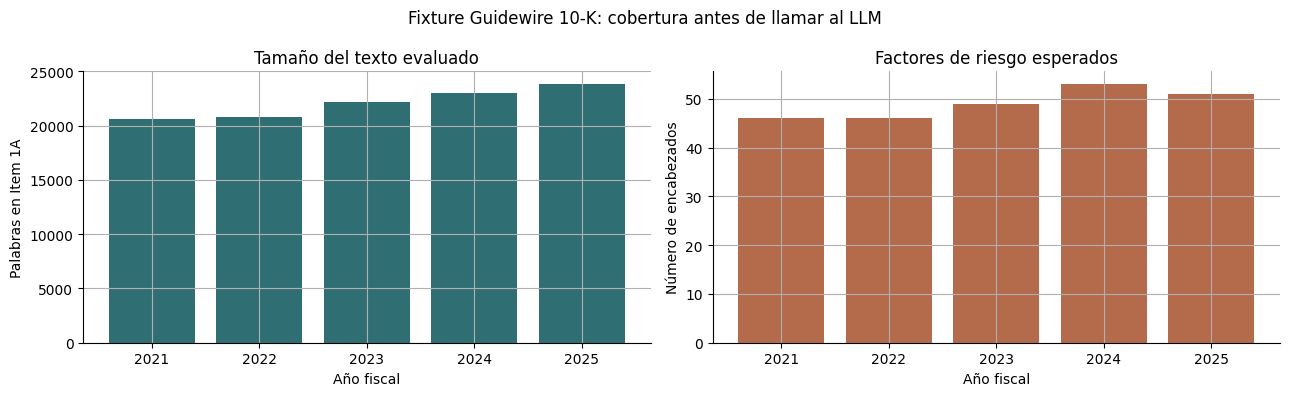

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(case_df['year'].astype(str), case_df['word_count'], color='#2f6f73')
axes[0].set_title('Tamaño del texto evaluado')
axes[0].set_xlabel('Año fiscal')
axes[0].set_ylabel('Palabras en Item 1A')

axes[1].bar(case_df['year'].astype(str), case_df['expected_risk_factors'], color='#b46b4c')
axes[1].set_title('Factores de riesgo esperados')
axes[1].set_xlabel('Año fiscal')
axes[1].set_ylabel('Número de encabezados')

fig.suptitle('Fixture Guidewire 10-K: cobertura antes de llamar al LLM')
fig.tight_layout()
plt.show()


## Ejecutar la evaluación completa

Esta celda ejecuta todos los casos disponibles en `eval.json`. El comportamiento por defecto del notebook es evaluar el fixture completo.

Los umbrales se dejan visibles para que el experimento sea reproducible:

- `MIN_RECALL`: mínimo recall exigido para pasar un caso.
- `MIN_PRECISION`: mínima precision exigida para pasar un caso.
- `MATCH_THRESHOLD`: similitud mínima entre un título esperado y un título predicho para considerarlos el mismo riesgo.


In [5]:
MIN_RECALL = DEFAULT_MIN_RECALL
MIN_PRECISION = DEFAULT_MIN_PRECISION
MATCH_THRESHOLD = DEFAULT_MATCH_THRESHOLD

client = DeepSeekClient.from_env(PROJECT_ROOT / '.env')
summary = run_risk_factor_listing_eval(
    client=client,
    eval_path=PROJECT_ROOT / 'eval.json',
    output_dir=PROJECT_ROOT / 'eval_runs',
    min_recall=MIN_RECALL,
    min_precision=MIN_PRECISION,
    match_threshold=MATCH_THRESHOLD,
)

{
    'run_id': summary.run_id,
    'output_dir': str(summary.output_dir),
    'cases_passed': summary.cases_passed,
    'cases_total': summary.cases_total,
    'all_passed': summary.all_passed,
}


{'run_id': '20260616T152632Z',
 'output_dir': 'PROJECT_ROOT/eval_runs/20260616T152632Z',
 'cases_passed': 5,
 'cases_total': 5,
 'all_passed': True}

## Resultados por caso

El runner guarda un `summary.json` y un fichero JSON por cada caso. Aquí los leemos para construir una tabla de métricas por año.


In [6]:
summary_path = summary.output_dir / 'summary.json'
with summary_path.open(encoding='utf-8') as handle:
    saved_summary = json.load(handle)

result_rows = []
for result in saved_summary['results']:
    score = result['score']
    usage = result.get('usage') or {}
    result_rows.append({
        'year': result['year'],
        'case_id': result['case_id'],
        'passed': score['passed'],
        'expected': score['expected_count'],
        'predicted': score['predicted_count'],
        'matched': score['matched_count'],
        'missing': len(score['missing']),
        'unexpected': len(score['unexpected']),
        'recall': score['recall'],
        'precision': score['precision'],
        'total_tokens': usage.get('total_tokens'),
        'prompt_tokens': usage.get('prompt_tokens'),
        'completion_tokens': usage.get('completion_tokens'),
        'case_result_path': result['case_result_path'],
    })

results_df = pd.DataFrame(result_rows).sort_values('year').reset_index(drop=True)
results_df


,year,case_id,passed,expected,predicted,matched,missing,unexpected,recall,precision,total_tokens,prompt_tokens,completion_tokens,case_result_path
0,2021,gwre-2021-10k-item-1a-risk-factor-listing,True,46,46,46,0,0,1.0,1.0,30662,24300,6362,PROJECT_ROOT/...
1,2022,gwre-2022-10k-item-1a-risk-factor-listing,True,46,46,46,0,0,1.0,1.0,32412,24493,7919,PROJECT_ROOT/...
2,2023,gwre-2023-10k-item-1a-risk-factor-listing,True,49,49,49,0,0,1.0,1.0,33453,26058,7395,PROJECT_ROOT/...
3,2024,gwre-2024-10k-item-1a-risk-factor-listing,True,53,53,53,0,0,1.0,1.0,35836,27041,8795,PROJECT_ROOT/...
4,2025,gwre-2025-10k-item-1a-risk-factor-listing,True,51,51,51,0,0,1.0,1.0,34795,27949,6846,PROJECT_ROOT/...


In [7]:
aggregate_metrics = {
    'run_id': saved_summary['run_id'],
    'model': saved_summary['model'],
    'cases_total': saved_summary['cases_total'],
    'cases_passed': saved_summary['cases_passed'],
    'pass_rate': round(saved_summary['cases_passed'] / saved_summary['cases_total'], 4),
    'all_passed': saved_summary['all_passed'],
    'expected_total': int(results_df['expected'].sum()),
    'predicted_total': int(results_df['predicted'].sum()),
    'matched_total': int(results_df['matched'].sum()),
    'missing_total': int(results_df['missing'].sum()),
    'unexpected_total': int(results_df['unexpected'].sum()),
    'avg_recall': round(float(results_df['recall'].mean()), 4),
    'avg_precision': round(float(results_df['precision'].mean()), 4),
    'total_tokens': int(results_df['total_tokens'].fillna(0).sum()),
}

pd.DataFrame([aggregate_metrics])


,run_id,model,cases_total,cases_passed,pass_rate,all_passed,expected_total,predicted_total,matched_total,missing_total,unexpected_total,avg_recall,avg_precision,total_tokens
0,20260616T152632Z,deepseek-v4-pro,5,5,1.0,True,245,245,245,0,0,1.0,1.0,167158


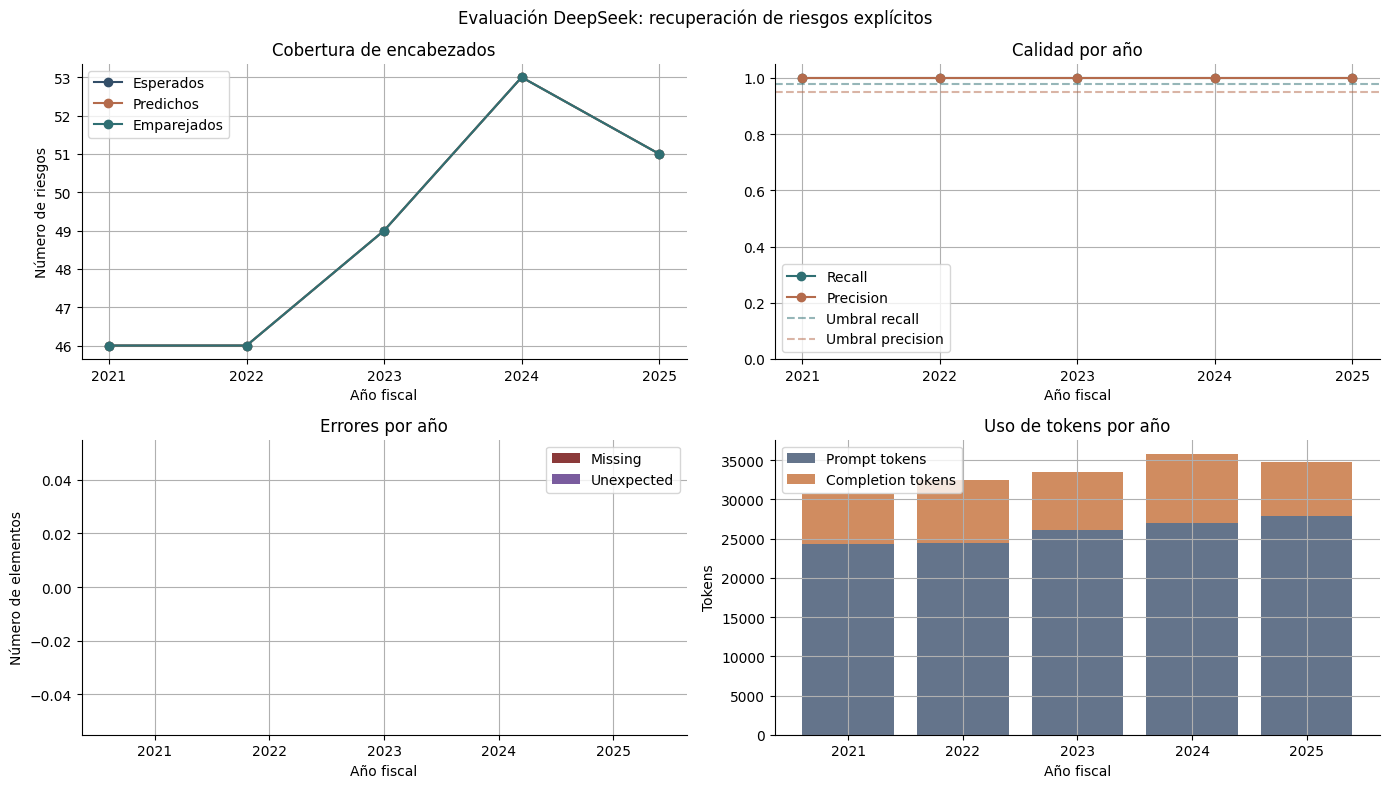

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
years = results_df['year'].astype(str)

axes[0, 0].plot(years, results_df['expected'], marker='o', label='Esperados', color='#334e68')
axes[0, 0].plot(years, results_df['predicted'], marker='o', label='Predichos', color='#b46b4c')
axes[0, 0].plot(years, results_df['matched'], marker='o', label='Emparejados', color='#2f6f73')
axes[0, 0].set_title('Cobertura de encabezados')
axes[0, 0].set_xlabel('Año fiscal')
axes[0, 0].set_ylabel('Número de riesgos')
axes[0, 0].legend()

axes[0, 1].plot(years, results_df['recall'], marker='o', label='Recall', color='#2f6f73')
axes[0, 1].plot(years, results_df['precision'], marker='o', label='Precision', color='#b46b4c')
axes[0, 1].axhline(MIN_RECALL, linestyle='--', color='#2f6f73', alpha=0.5, label='Umbral recall')
axes[0, 1].axhline(MIN_PRECISION, linestyle='--', color='#b46b4c', alpha=0.5, label='Umbral precision')
axes[0, 1].set_title('Calidad por año')
axes[0, 1].set_xlabel('Año fiscal')
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].legend()

axes[1, 0].bar(years, results_df['missing'], label='Missing', color='#8b3a3a')
axes[1, 0].bar(years, results_df['unexpected'], bottom=results_df['missing'], label='Unexpected', color='#7a5c9e')
axes[1, 0].set_title('Errores por año')
axes[1, 0].set_xlabel('Año fiscal')
axes[1, 0].set_ylabel('Número de elementos')
axes[1, 0].legend()

if results_df['total_tokens'].notna().any():
    axes[1, 1].bar(years, results_df['prompt_tokens'].fillna(0), label='Prompt tokens', color='#64748b')
    axes[1, 1].bar(
        years,
        results_df['completion_tokens'].fillna(0),
        bottom=results_df['prompt_tokens'].fillna(0),
        label='Completion tokens',
        color='#d08c60',
    )
    axes[1, 1].set_title('Uso de tokens por año')
    axes[1, 1].set_xlabel('Año fiscal')
    axes[1, 1].set_ylabel('Tokens')
    axes[1, 1].legend()
else:
    axes[1, 1].axis('off')
    axes[1, 1].text(0.5, 0.5, 'No token usage returned', ha='center', va='center')

fig.suptitle('Evaluación DeepSeek: recuperación de riesgos explícitos')
fig.tight_layout()
plt.show()


## Análisis de errores

Si el modelo falla, esta sección muestra exactamente qué faltó (`missing`) y qué añadió de más (`unexpected`). Esto es importante porque no queremos una métrica opaca: queremos saber si los errores son simples diferencias de redacción, riesgos duplicados, omisiones reales o invenciones.


In [9]:
missing_rows = []
unexpected_rows = []
match_rows = []

for result in saved_summary['results']:
    year = result['year']
    score = result['score']
    for item in score['missing']:
        missing_rows.append({'year': year, **item})
    for item in score['unexpected']:
        unexpected_rows.append({'year': year, **item})
    for item in score['matches']:
        match_rows.append({'year': year, **item})

if missing_rows:
    display(Markdown('### Missing'))
    display(pd.DataFrame(missing_rows))
else:
    display(Markdown('### Missing\nNo hay factores de riesgo esperados sin recuperar.'))

if unexpected_rows:
    display(Markdown('### Unexpected'))
    display(pd.DataFrame(unexpected_rows))
else:
    display(Markdown('### Unexpected\nNo hay factores de riesgo inesperados en la salida del modelo.'))

matches_df = pd.DataFrame(match_rows)
if not matches_df.empty:
    display(Markdown('### Peores emparejamientos aceptados'))
    display(matches_df.sort_values('similarity').head(10))


### Missing
No hay factores de riesgo esperados sin recuperar.

### Unexpected
No hay factores de riesgo inesperados en la salida del modelo.

### Peores emparejamientos aceptados

,year,expected_order,predicted_order,expected_title,predicted_title,similarity
0,2021,1,1,The global COVID-19 pandemic has adversely aff...,The global COVID-19 pandemic has adversely aff...,1.0
155,2024,15,15,Our ability to sell our products is highly dep...,Our ability to sell our products is highly dep...,1.0
156,2024,16,16,The use of AI by our workforce may present ris...,The use of AI by our workforce may present ris...,1.0
157,2024,17,17,"Revenue mix, as well as declines in our subscr...","Revenue mix, as well as declines in our subscr...",1.0
158,2024,18,18,Failure of any of our established products to ...,Failure of any of our established products to ...,1.0
159,2024,19,19,If we are unable to continue the successful de...,If we are unable to continue the successful de...,1.0
160,2024,20,20,Our international sales and operations subject...,Our international sales and operations subject...,1.0
161,2024,21,21,We may expand through acquisitions or partners...,We may expand through acquisitions or partners...,1.0
162,2024,22,22,Incorrect or improper use of our products or o...,Incorrect or improper use of our products or o...,1.0
163,2024,23,23,We may not be able to obtain capital when desi...,We may not be able to obtain capital when desi...,1.0


## Cómo interpretar este baseline

Si este eval pasa, significa que el modelo puede leer un `Item 1A` largo y reconstruir los riesgos explícitos listados por la compañía con alta fidelidad. Eso nos da confianza para la siguiente fase.

Lo que todavía no mide:

- No detecta riesgos ocultos.
- No compara años consecutivos.
- No usa `MD&A`.
- No valida tono, contradicciones ni aparición/desaparición de temas.

La siguiente evaluación debería usar pares de años, por ejemplo `2024 -> 2025`, y pedir al modelo evidencias concretas de cambios de tono, contradicciones o riesgos implícitos no declarados claramente.
